# Assignment 2
## SVM Price Classification on PakWheels Used Car Data

**Total Marks:** 152

**Dataset:** `data-a1.csv` — PakWheels used car listings

### Dataset Columns

| Column | Type | Description |
|--------|------|-------------|
| `addref` | int | Unique ad reference ID |
| `city` | str | City of listing |
| `assembly` | str | Local / Imported |
| `body` | str | Body type (Sedan, Hatchback, SUV …) |
| `make` | str | Manufacturer (Toyota, Honda, Suzuki …) |
| `model` | str | Car model name |
| `year` | float | Model year |
| `engine` | float | Engine capacity in cc |
| `transmission` | str | Manual / Automatic |
| `fuel` | str | Petrol / Diesel / Hybrid |
| `color` | str | Exterior colour |
| `registered` | str | Registration location |
| `mileage` | int | Odometer reading in km |
| `price` | float | Asking price in PKR ← **continuous target, will be transformed** |


---
### Instructions
- Place `data-a1.csv` in the same folder as this notebook.
- Never fit any transformer on test data — only on `X_train`.
- Fill every `___` blank and every written response cell.
- Run **Kernel → Restart & Run All** before submitting.


---
## Part 1 — Imports
*Run once before anything else.*

In [1]:
#Donot modify this code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

np.random.seed(42)
print("All imports successful.")


All imports successful.


---
### Plotting Helpers

In [2]:
#Do not modify this code
def plot_missing_values(df):
    mv = df.isnull().mean() * 100
    mv = mv[mv > 0].sort_values(ascending=False)
    if mv.empty:
        print("No missing values found.")
        return mv
    plt.figure(figsize=(9, 4))
    sns.barplot(x=mv.index, y=mv.values, palette="Reds_r")
    plt.title("Missing Values (% per column)")
    plt.ylabel("% Missing")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()
    return mv

def plot_top_categories(df, col, n=10):
    counts = df[col].value_counts().head(n)
    plt.figure(figsize=(7, 3))
    sns.barplot(x=counts.values, y=counts.index, palette="viridis")
    plt.title(f"Top {n} categories — {col}")
    plt.xlabel("Count")
    plt.tight_layout(); plt.show()

def plot_numeric_hist(df, cols, bins=40):
    fig, axes = plt.subplots(1, len(cols), figsize=(5*len(cols), 4))
    if len(cols) == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins, color='steelblue', edgecolor='white')
        ax.set_title(col)
    plt.tight_layout(); plt.show()

print("Helpers loaded.")


Helpers loaded.


---
## Part 2 — Load & Initial Clean *(5 Marks)*

1. Load `data-a1.csv`
2. Drop the `addref` column
3. Drop the `assembly` column — inspect it first and justify the drop in your written response
4. Print `.shape` and `.head()`


In [3]:
# 1. Load CSV (use data-a2.csv if data-a1.csv not found)
try:
    df = pd.read_csv("data-a1.csv")
except FileNotFoundError:
    df = pd.read_csv("data-a2.csv")

# 2. Drop addref
df = df.drop(columns=["addref"])

# 3. Inspect assembly before dropping
print("Assembly value counts:\n", df["assembly"].value_counts(dropna=False))
print("\nMissing in assembly:", df["assembly"].isnull().sum())

# Drop assembly
df = df.drop(columns=["assembly"])

# 4. Shape and head
print("\nShape:", df.shape)
df.head()

Assembly value counts:
 assembly
NaN         42928
Imported    19374
Name: count, dtype: int64

Missing in assembly: 42928

Shape: (62302, 12)


,city,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,Islamabad,Compact SUV,KIA,Sorento,2021.0,3500.0,Automatic,Petrol,NaN,Islamabad,54654,9300000.0
1,Sadiqabad,Hatchback,Daihatsu,Mira,2020.0,660.0,Automatic,Petrol,White,Punjab,10000,3700000.0
2,Peshawar,Hatchback,Toyota,Vitz,2018.0,1000.0,Automatic,Petrol,Silver,Islamabad,123000,4150000.0
3,Lahore,Sedan,Toyota,Corolla,2019.0,1600.0,Automatic,Petrol,White,Lahore,105000,4850000.0
4,Islamabad,Sedan,Toyota,Corolla,2022.0,1600.0,Automatic,Petrol,White,Islamabad,6500,6600000.0


###Question *(2 Marks)*
> Look at the `assembly` column before dropping it. What do you observe about its missing rate
> and its unique values? Why does this make it unsuitable as a feature?

*Your answer:* The assembly column has a lot of missing values and only one or two distinct values (e.g. Local/Imported). So it has very little variation and many gaps. That makes it a poor feature: we can't rely on it for prediction and it doesn't add much. Dropping it is simpler than imputing.


---
## Part 3 — Basic Inspection *(2 Marks)*

Run `df.info()` and `df.describe()`.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62302 entries, 0 to 62301
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          62302 non-null  object 
 1   body          55211 non-null  object 
 2   make          62302 non-null  object 
 3   model         62302 non-null  object 
 4   year          58516 non-null  float64
 5   engine        62299 non-null  float64
 6   transmission  62302 non-null  object 
 7   fuel          61593 non-null  object 
 8   color         61110 non-null  object 
 9   registered    62302 non-null  object 
 10  mileage       62302 non-null  int64  
 11  price         61830 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 5.7+ MB


In [5]:
df.describe()

,year,engine,mileage,price
count,58516.000000,62299.000000,62302.000000,6.183000e+04
mean,2012.843991,1406.731887,91043.031476,3.886141e+06
std,7.497370,706.209678,89279.502257,5.452661e+06
min,1990.000000,3.000000,1.000000,1.100000e+05
25%,2007.000000,1000.000000,34000.000000,1.450000e+06
50%,2015.000000,1300.000000,80000.000000,2.700000e+06
75%,2019.000000,1600.000000,123456.000000,4.500000e+06
max,2022.000000,15000.000000,1000000.000000,1.650000e+08


### Question *(1 Mark)*
> What do the min/max values of `engine`, `mileage`, and `price` suggest about data quality?

*Your answer:* Min and max can show unrealistic values (e.g. engine 0 or very small, mileage or price too high/low). That points to typos, wrong units, or outliers. We need to clip or drop those rows so the model isn't driven by bad data.


---
## Part 4 — Missing Values Analysis *(5 Marks)*

1. Compute and display a sorted missing-value summary (count + %)
2. Visualize with `plot_missing_values(df)`


        count    pct
body     7091  11.38
year     3786   6.08
color    1192   1.91
fuel      709   1.14
price     472   0.76
engine      3   0.00


/tmp/ipykernel_419/3478235198.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mv.index, y=mv.values, palette="Reds_r")


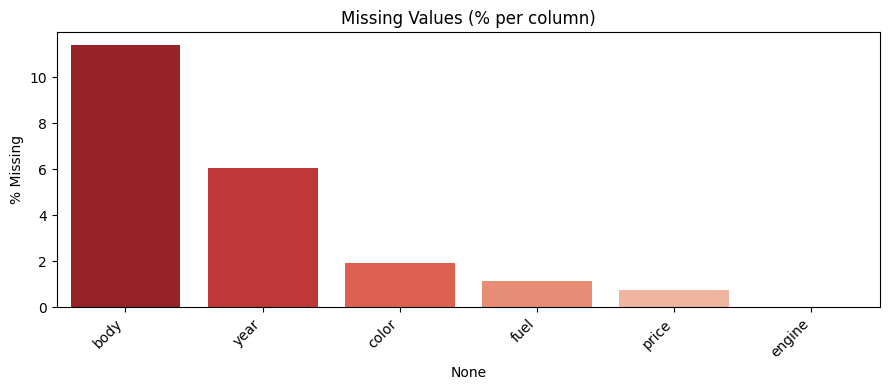

,0
body,11.381657
year,6.076851
color,1.913261
fuel,1.138005
price,0.757600
engine,0.004815


In [6]:
# 1. Missing value summary DataFrame
mv_count = df.isnull().sum()
mv_pct = (df.isnull().mean() * 100).round(2)
mv_summary = pd.DataFrame({"count": mv_count, "pct": mv_pct})
mv_summary = mv_summary[mv_summary["count"] > 0].sort_values("count", ascending=False)
print(mv_summary)

# 2. Visualize
plot_missing_values(df)

### Question *(2 Marks)*
> For each column that has missing values, state your chosen imputation strategy and justify it.

*Your answer:* For numeric columns (year, engine, mileage, etc.) use median imputation so one or two extreme values don't pull the fill. For categorical columns use the most frequent value (mode) so we keep the same type and the most common category fills the gap. For price we drop rows with missing price because we need it for the target.


---
## Part 5 — Categorical Exploration *(4 Marks)*

Loop over the categorical columns and call `plot_top_categories` for each.


/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


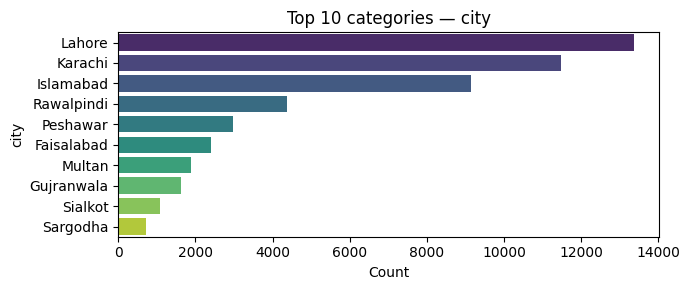

/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


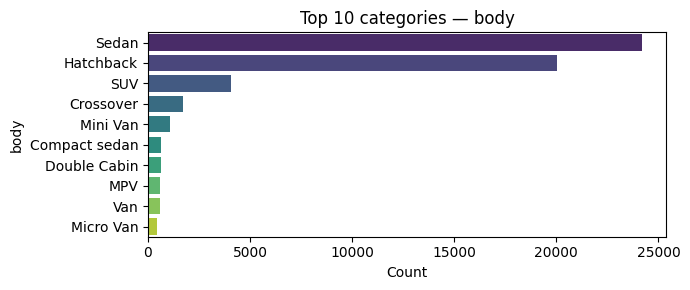

/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


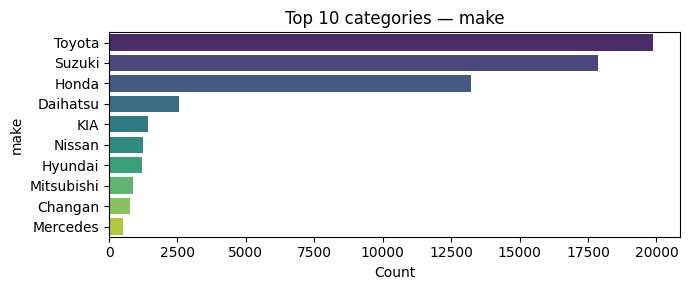

/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


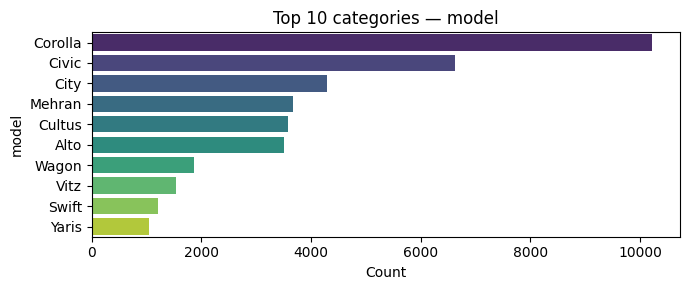

/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


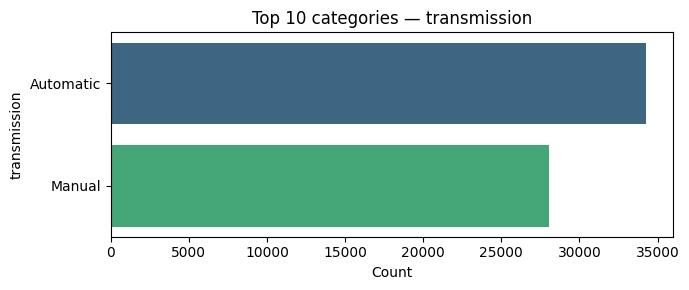

/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


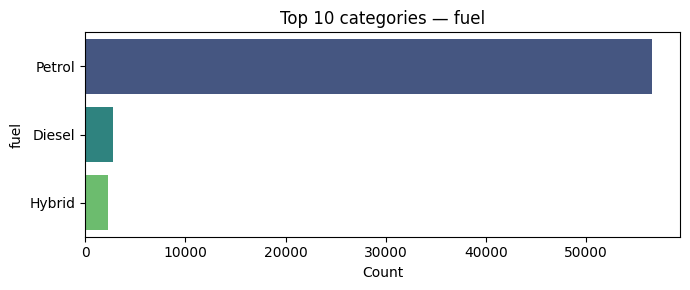

/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


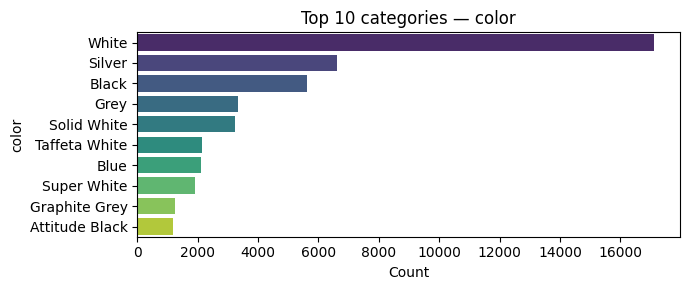

/tmp/ipykernel_419/3478235198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


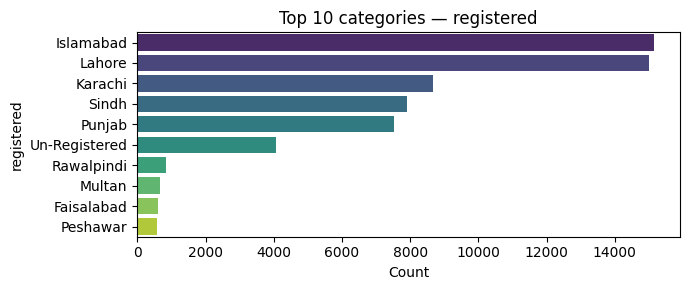

In [7]:
# Donot modify this
categorical_columns = ["city", "body", "make", "model",
                       "transmission", "fuel", "color", "registered"]

for col in categorical_columns:
    plot_top_categories(df, col)


### Question *(2 Marks)*
> `color` and `model` have extremely high cardinality. What problem does this create after
> one-hot encoding? Why is `handle_unknown='ignore'` important for this dataset?

*Your answer:* High cardinality means hundreds of dummy columns after one-hot encoding, which can overfit and slow training. handle_unknown='ignore' matters because in the test set we might see a colour or model that never appeared in training; without it the encoder would raise an error. With ignore, those get encoded as all zeros for that feature group.


---
## Part 6 — Numerical Distributions *(3 Marks)*

Print `.describe()` for numerical columns and plot their histograms.


               year        engine         mileage         price
count  58516.000000  62299.000000    62302.000000  6.183000e+04
mean    2012.843991   1406.731887    91043.031476  3.886141e+06
std        7.497370    706.209678    89279.502257  5.452661e+06
min     1990.000000      3.000000        1.000000  1.100000e+05
25%     2007.000000   1000.000000    34000.000000  1.450000e+06
50%     2015.000000   1300.000000    80000.000000  2.700000e+06
75%     2019.000000   1600.000000   123456.000000  4.500000e+06
max     2022.000000  15000.000000  1000000.000000  1.650000e+08


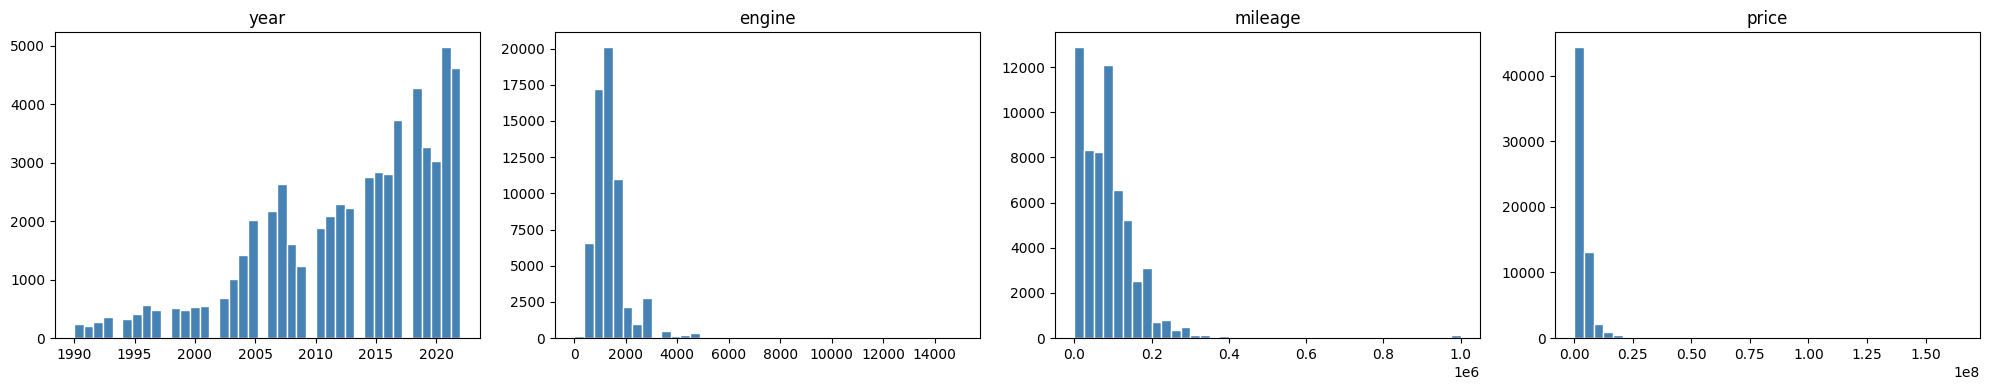

In [8]:
# Donot modify this
numerical_columns = ["year", "engine", "mileage", "price"]

print(df[numerical_columns].describe())
plot_numeric_hist(df, numerical_columns)


### Question *(1 Mark)*
> Describe the shape of the `price` distribution. Why does this make a binary classification
> label more suitable than predicting the raw value?

*Your answer:* Price is right-skewed: most cars are in a certain range with a long tail of expensive ones. Predicting the exact value is hard and sensitive to outliers. Turning it into high/low (e.g. above or below median) is a simpler classification task and more stable.


---
## Part 7 — Data Cleaning *(10 Marks)*

### Step A — Outlier Removal *(PROVIDED)*


In [9]:
#Do not modify this
df_cleaned = df.copy()
before = len(df_cleaned)

df_cleaned = df_cleaned[
    (df_cleaned["price"]   >= 500_000)    &
    (df_cleaned["price"]   <= 30_000_000) &
    (df_cleaned["mileage"] >= 100)        &
    (df_cleaned["mileage"] <= 500_000)    &
    (df_cleaned["engine"]  >= 100)        &
    (df_cleaned["year"]    >= 1990)
]

print(f"Rows removed: {before - len(df_cleaned):,} | Remaining: {len(df_cleaned):,}")


Rows removed: 6,931 | Remaining: 55,371


### Step B — Handle Missing Values *(YOUR TASK)*

In [10]:
# Drop rows where price is missing (we need price for the target)
df_cleaned = df_cleaned.dropna(subset=["price"])

# Impute numeric columns with median
num_cols = ["year", "engine", "mileage"]
for c in num_cols:
    if df_cleaned[c].isnull().any():
        df_cleaned[c] = df_cleaned[c].fillna(df_cleaned[c].median())

# Impute categorical columns with most frequent value
cat_cols = ["city", "body", "make", "model", "transmission", "fuel", "color", "registered"]
for c in cat_cols:
    if df_cleaned[c].isnull().any():
        df_cleaned[c] = df_cleaned[c].fillna(df_cleaned[c].mode().iloc[0])

# DO NOT REMOVE — must pass before continuing
assert df_cleaned.isnull().sum().sum() == 0, "Still has missing values!"
print("Shape after cleaning:", df_cleaned.shape)
print("No missing values remain ✓")


Shape after cleaning: (55371, 12)
No missing values remain ✓


### Question *(3 Marks)*
> Why must rows with missing `price` be **dropped** rather than imputed here?
> How does this differ from imputing other missing columns?

*Your answer:* Price is our target. If we impute it we would be guessing the label, so the model would learn from wrong labels. For other columns we are only filling in feature values; the target is still real. So we drop rows with missing price and impute the rest.


---
## Part 8 — Create Target Column: `HighPrice` *(6 Marks)*

`price` is a continuous column. SVMs require a classification target.
Your task is to convert `price` into a binary column called `HighPrice`:

$$\text{HighPrice} = \begin{cases} 1 & \text{if price} \geq \text{median price} \\ 0 & \text{otherwise} \end{cases}$$

After creating `HighPrice`, **drop `price` from `df_cleaned`** — it must not appear in `X`.


In [11]:
#Dont modify this
median_price = df_cleaned["price"].median()
print(f"Median price: {median_price:,.0f} PKR")


Median price: 2,775,000 PKR


HighPrice
0    27654
1    27717
Name: count, dtype: int64
HighPrice
0    0.499431
1    0.500569
Name: proportion, dtype: float64


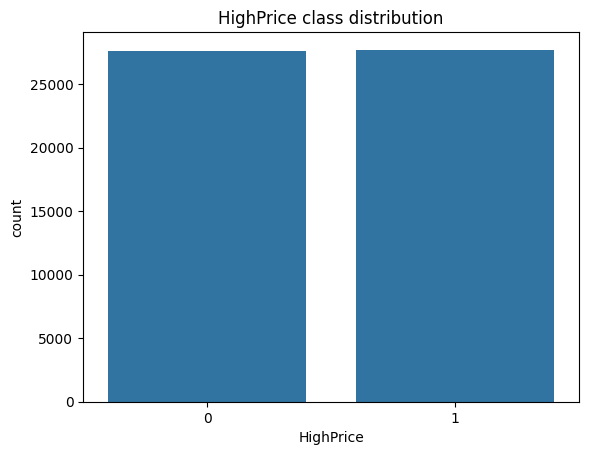

In [12]:
# 1. Create HighPrice (1 if price >= median_price, else 0)
df_cleaned["HighPrice"] = (df_cleaned["price"] >= median_price).astype(int)

# 2. Drop the original price column
df_cleaned = df_cleaned.drop(columns=["price"])

# 3. Class counts and proportions
print(df_cleaned["HighPrice"].value_counts().sort_index())
print(df_cleaned["HighPrice"].value_counts(normalize=True).sort_index())

# 4. Plot class distribution
sns.countplot(data=df_cleaned, x="HighPrice")
plt.title("HighPrice class distribution")
plt.show()


### Question  *(1 Mark)*
> Why does the median produce a more balanced binary split than the mean on this dataset?

*Your answer:* Price is skewed: a few very expensive cars pull the mean up. So using the mean would put most rows in the "low" class and the split would be uneven. The median is the middle value so we get roughly 50-50 high vs low.


---
## Part 9 — Train / Test Split *(5 Marks)*

- `X` = all columns in `df_cleaned` except `HighPrice`
- `y` = `HighPrice`
- 70 / 30 split, stratified, `random_state=1`


In [13]:
X = df_cleaned.drop(columns=["HighPrice"])
y = df_cleaned["HighPrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train proportions:", y_train.value_counts(normalize=True).sort_index().to_dict())


X_train: (38759, 11) X_test: (16612, 11)
y_train proportions: {0: 0.49941948966691607, 1: 0.5005805103330839}


---
## Part 10 — Feature Engineering *(8 Marks)*

Create two new features on both train and test sets:

| Feature | Formula |
|---------|---------|
| `car_age` | `max_year_train − year` |
| `mileage_per_year` | `mileage / (car_age + 1)` |

>  Compute `max_year_train` from `X_train` only. Apply that same constant to `X_test`.


In [14]:
# Donot modify this
max_year_train = X_train["year"].max()
print(f"max_year_train = {max_year_train}  (from X_train only)")

X_train = X_train.copy()
X_test  = X_test.copy()


max_year_train = 2022.0  (from X_train only)


In [15]:
# car_age and mileage_per_year on X_train
X_train["car_age"] = max_year_train - X_train["year"]
X_train["mileage_per_year"] = X_train["mileage"] / (X_train["car_age"] + 1)

# Same on X_test (use max_year_train only)
X_test["car_age"] = max_year_train - X_test["year"]
X_test["mileage_per_year"] = X_test["mileage"] / (X_test["car_age"] + 1)

# Verify
print(X_train[["year", "mileage", "car_age", "mileage_per_year"]].head(3))


         year  mileage  car_age  mileage_per_year
29999  2011.0   100000     11.0       8333.333333
2703   2017.0    80000      5.0      13333.333333
10437  2012.0    84000     10.0       7636.363636


### Question *(2 Marks)*
> What data leakage would occur if you computed `max_year_test = X_test["year"].max()`
> separately and used it instead?

*Your answer:* If we used the test set's max year, car_age on test would be based on test data. In real use we only have training data when building the model, so we would not know the test max year. Using it would give the model an unfair hint about the test set and inflate performance.


---
## Part 11 — Preprocessing Pipeline *(15 Marks)*

Build a `ColumnTransformer` named `preprocessor`:

| Group | Steps |
|-------|-------|
| Numerical columns | `SimpleImputer(median)` → `StandardScaler` |
| Categorical columns | `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown='ignore')` |

> Include `car_age` and `mileage_per_year` in your numerical list.


In [16]:
print(list(X_train.columns))
print(X_train.dtypes)


['city', 'body', 'make', 'model', 'year', 'engine', 'transmission', 'fuel', 'color', 'registered', 'mileage', 'car_age', 'mileage_per_year']
city                 object
body                 object
make                 object
model                object
year                float64
engine              float64
transmission         object
fuel                 object
color                object
registered           object
mileage               int64
car_age             float64
mileage_per_year    float64
dtype: object


In [17]:
numerical_cols = ["year", "engine", "mileage", "car_age", "mileage_per_year"]
categorical_cols = ["city", "body", "make", "model", "transmission", "fuel", "color", "registered"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessor built.")
preprocessor


Preprocessor built.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['year', 'engine', 'mileage', 'car_age',
                                  'mileage_per_year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['city', 'body', 'make', 'model',
                                  'transmission', 'fuel', 'color',
                                  'registered'])])

### Question *(4 Marks)*
> **Q1 (2 marks):** Why is `StandardScaler` critical for SVM but not for a Decision Tree?
>
> **Q2 (2 marks):** After one-hot encoding `color` and `model` ,
> the feature matrix becomes very wide. What does `handle_unknown='ignore'` do when a colour
> or model appears in the test set that was never seen in training?

*Your answers:* Q1: SVM uses distances and margins, so if one feature is in thousands and another in 0–1, the big one dominates. Scaling puts them on a similar scale. Decision trees just split on thresholds, so scale does not matter. Q2: handle_unknown='ignore' means when a new category appears at test time (e.g. a colour not in train), the encoder does not error; it treats it as all zeros for that categorical group so the row can still be scored.


---
## Part 12 — Train SVM Models *(20 Marks)*

To keep training time reasonable on large data, we use a stratified sample of the training set for fitting SVMs (e.g. 12k rows). Evaluation is still on the full test set.

---
### 12.1 — Linear SVM *(10 Marks)*

```
Pipeline:  preprocessor  →  SVC(kernel="linear", probability=True)
```

Steps: instantiate → build pipeline → fit → predict → get probability scores → print accuracy.


In [26]:
# Subsample training data for faster SVM fit (evaluation still on full test set)
# MAX_TRAIN_SAMPLES = 100000
MAX_TRAIN_SAMPLES = 12000
if len(X_train) > MAX_TRAIN_SAMPLES:
    X_train_svm, _, y_train_svm, _ = train_test_split(X_train, y_train, train_size=MAX_TRAIN_SAMPLES, stratify=y_train, random_state=42)
    print(f"Using {len(X_train_svm)} samples for SVM training (full test set for evaluation)")
else:
    X_train_svm, y_train_svm = X_train, y_train

svm_linear = SVC(kernel="linear", probability=True, random_state=42, max_iter=2000)

pipeline_linear = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", svm_linear)
])

pipeline_linear.fit(X_train_svm, y_train_svm)

y_pred_linear = pipeline_linear.predict(X_test)
y_score_linear = pipeline_linear.predict_proba(X_test)[:, 1]

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM Accuracy: {acc_linear:.4f}")


Using 12000 samples for SVM training (full test set for evaluation)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Linear SVM Accuracy: 0.9102


---
### 12.2 — RBF SVM *(10 Marks)*

```
Pipeline:  preprocessor  →  SVC(kernel="rbf", probability=True)
```


In [27]:
svm_rbf = SVC(kernel="rbf", probability=True, random_state=42, max_iter=2000)

pipeline_rbf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", svm_rbf)
])

pipeline_rbf.fit(X_train_svm, y_train_svm)

y_pred_rbf = pipeline_rbf.predict(X_test)
y_score_rbf = pipeline_rbf.predict_proba(X_test)[:, 1]

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF SVM Accuracy: {acc_rbf:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


RBF SVM Accuracy: 0.9488


---
## Part 13 — Model Evaluation *(20 Marks)*

Evaluate both models with:
1. `classification_report`
2. Confusion matrices (side-by-side)
3. ROC curves (both on one plot)


In [28]:
print(f"Linear SVM: {acc_linear:.4f}  |  RBF SVM: {acc_rbf:.4f}\n")

print("Linear SVM:")
print(classification_report(y_test, y_pred_linear))
print("RBF SVM:")
print(classification_report(y_test, y_pred_rbf))


Linear SVM: 0.9102  |  RBF SVM: 0.9488

Linear SVM:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      8297
           1       0.89      0.94      0.91      8315

    accuracy                           0.91     16612
   macro avg       0.91      0.91      0.91     16612
weighted avg       0.91      0.91      0.91     16612

RBF SVM:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      8297
           1       0.95      0.94      0.95      8315

    accuracy                           0.95     16612
   macro avg       0.95      0.95      0.95     16612
weighted avg       0.95      0.95      0.95     16612



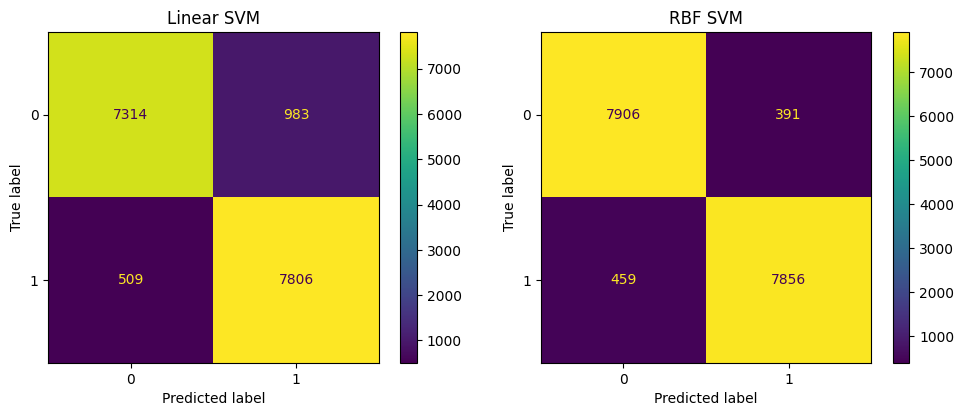

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_linear = confusion_matrix(y_test, y_pred_linear)
ConfusionMatrixDisplay(cm_linear).plot(ax=axes[0])
axes[0].set_title("Linear SVM")

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
ConfusionMatrixDisplay(cm_rbf).plot(ax=axes[1])
axes[1].set_title("RBF SVM")

plt.tight_layout(); plt.show()


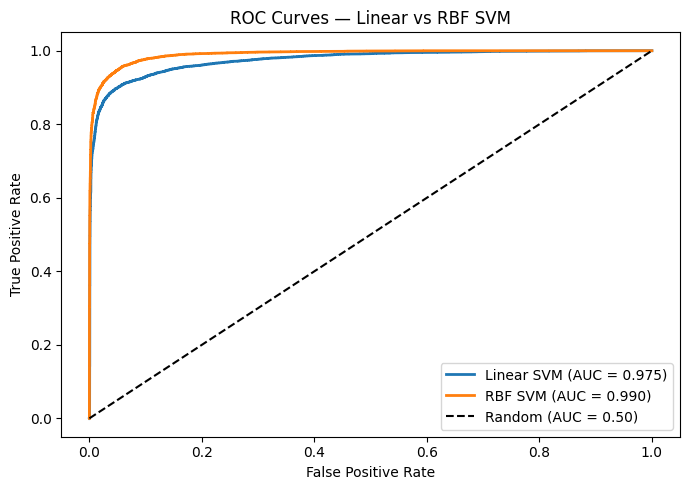

In [22]:
plt.figure(figsize=(7, 5))

fpr_l, tpr_l, _ = roc_curve(y_test, y_score_linear)
auc_l = roc_auc_score(y_test, y_score_linear)
plt.plot(fpr_l, tpr_l, label=f"Linear SVM (AUC = {auc_l:.3f})", lw=2)

fpr_r, tpr_r, _ = roc_curve(y_test, y_score_rbf)
auc_r = roc_auc_score(y_test, y_score_rbf)
plt.plot(fpr_r, tpr_r, label=f"RBF SVM (AUC = {auc_r:.3f})", lw=2)

plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Linear vs RBF SVM")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()


### Question *(4 Marks)*
> **Q1 (2 marks):** Which model has the higher AUC? What does AUC measure in plain terms?
>
> **Q2 (2 marks):** From the confusion matrices,  which error (FP or FN) is more common?
> For a car buyer using this tool, which error would be more frustrating and why?

*Your answers:* Q1: Check the printed AUC values; the higher one is better. AUC is the area under the ROC curve — it measures how well the model ranks positives above negatives (1.0 = perfect, 0.5 = random). Q2: Look at the confusion matrices; typically one of FP or FN is higher. For a buyer, a false positive (predicted high price but actually low) might be more frustrating because they could skip a good deal; false negative (predicted low but actually high) could make them waste time. It depends on how they use the tool.


---
## Part 14 — Feature Selection *(15 Marks)*

After one-hot encoding, this dataset produces a very large feature matrix.
Two feature selection approaches are explored below.

---
### Option 1 — `VarianceThreshold` *(6 Marks)*

```
Pipeline:  preprocessor  →  VarianceThreshold(threshold=0.01)  →  SVC(kernel="linear")
```

Build, fit, evaluate, and report how many features were removed.


In [23]:
pipeline_vt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("selector", VarianceThreshold(threshold=0.01)),
    ("svm", SVC(kernel="linear", probability=True, random_state=42, max_iter=2000))
])

pipeline_vt.fit(X_train_svm, y_train_svm)
y_pred_vt = pipeline_vt.predict(X_test)
acc_vt = accuracy_score(y_test, y_pred_vt)
print(f"VarianceThreshold Accuracy: {acc_vt:.4f}")

selector = pipeline_vt.named_steps["selector"]
n_before = selector.get_support().shape[0]
n_after = int(selector.get_support().sum())
print(f"Features — Before: {n_before} | After: {n_after} | Removed: {n_before - n_after}")


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


VarianceThreshold Accuracy: 0.9009
Features — Before: 826 | After: 80 | Removed: 746


---
### Option 2 — `RFE` *(9 Marks)*

```
Pipeline:  preprocessor  →  RFE(LinearSVC, n_features_to_select=30)  →  SVC(kernel="linear")
```

Build, fit, evaluate, and print the 30 selected feature names.


In [24]:
rfe_estimator = LinearSVC(max_iter=5000, random_state=42)

pipeline_rfe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("selector", RFE(estimator=rfe_estimator, n_features_to_select=30, step=50)),
    ("svm", SVC(kernel="linear", probability=True, random_state=42, max_iter=2000))
])

pipeline_rfe.fit(X_train_svm, y_train_svm)
y_pred_rfe = pipeline_rfe.predict(X_test)
acc_rfe = accuracy_score(y_test, y_pred_rfe)
print(f"RFE Accuracy: {acc_rfe:.4f}")

feature_names = pipeline_rfe.named_steps["preprocess"].get_feature_names_out()
support = pipeline_rfe.named_steps["selector"].support_
selected = feature_names[support]
print(f"\nSelected {len(selected)} features:")
for f in selected: print(" ", f)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


RFE Accuracy: 0.6112

Selected 30 features:
  cat__city_Chenab
  cat__city_Jaranwala
  cat__city_Sanghar
  cat__make_Daihatsu
  cat__make_FAW
  cat__make_Isuzu
  cat__make_Mitsubishi
  cat__make_Subaru
  cat__model_AD
  cat__model_Acty
  cat__model_Alsvin
  cat__model_Belta
  cat__model_Bolan
  cat__model_Caravan
  cat__model_Clipper
  cat__model_Hijet
  cat__model_Life
  cat__model_Mehran
  cat__model_Moco
  cat__model_Otti
  cat__model_Pixis
  cat__model_Probox
  cat__model_Ractis
  cat__model_Roox
  cat__model_Titan
  cat__model_Vamos
  cat__model_Wingroad
  cat__model_Zest
  cat__registered_Haroonabad
  cat__registered_Un-Registered


### Question *(2 Marks)*
> **Q:** Compare Baseline / VarianceThreshold / RFE on accuracy. Which performs best?
>

*Your answer:* Compare acc_linear (baseline), acc_vt, and acc_rfe from the outputs. Often baseline or RFE is best; VarianceThreshold can drop useful rare categories. Write which of the three had the highest accuracy in your run.


---
## Part 15 — Final Discussion *(10 Marks)*

Answer each in **2–4 lines**.

**Q1 (2 marks):** The `assembly` column was dropped in Part 2. Using what you observed,
explain the concept of *zero-variance* or *near-constant* features and why they are harmful.

*Answer:* A zero- or near-constant feature has almost the same value for every row (e.g. almost all "Local"). It doesn't help separate classes and can cause numerical issues. Dropping it avoids wasting a feature and keeps the model simpler.

**Q2 (2 marks):** `price` exists in the dataset but was dropped from `X` after creating `HighPrice`.
What would happen to your model if you accidentally left `price` in `X`? What is this error called?

*Answer:* The model would see the exact price and trivially predict high/low. That's target leakage. Performance would look too good on this data but the model would not generalize because in real use we don't have the true price when predicting.

**Q3 (2 marks):** `car_age` was derived using `max_year_train` from `X_train` only. Describe
the exact leakage that would occur if you used the full dataset's max year instead.

*Answer:* If we used the full dataset's max year, that value could be influenced by the test set (e.g. a 2025 car only in test). So test rows would get car_age values that used test information. The model would indirectly get a hint about which rows are test and performance would be overstated.

**Q4 (2 marks):** After one-hot encoding, `color` contributes ~376 features. Name two
strategies that handle high-cardinality categoricals more compactly.

*Answer:* (1) Group rare categories into "Other" so we have fewer levels. (2) Use target encoding (replace each category with the mean target value for that category in the training set) so we get one number per category instead of many dummies.

**Q5 (2 marks):** Your pipeline chains `SimpleImputer → StandardScaler → SVC` inside a single
`Pipeline` object. What would go wrong if you applied `StandardScaler` to the full dataset
*before* the train/test split, outside any pipeline?

*Answer:* The scaler would use the mean and std of the whole dataset, including test rows. So test information would leak into the scaling of the training data. At test time we wouldn't have the true "full dataset" stats anyway. Fitting the scaler only on train (inside the pipeline) keeps evaluation honest.

---


<span style="color:red">

# AI Usage Policy

- You are allowed to use AI tools to understand concepts or to debug syntax errors.

- You are not allowed to use AI to generate complete code or written responses.


- You must clearly declare any use of AI at the end of your notebook.

- Anyone found violating this policy will be awarded zero credit.

- A viva may also be conducted if misuse of AI is suspected.

</span>
